In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import nan
%run opentable.ipynb
plt.rcParams["figure.figsize"] = (15,2)



path_order = "/Gdrive/zl/l2_trade/hout/orders.csv"
path_nps = "/data2/run/highres.s/data/nps.csv"

sids = [
    {"exchange":"okxswap", "sid":0},
    {"exchange":"binanceswap", "sid":1},
    {"exchange":"bybitswap", "sid":2},
    {"exchange":"binancespot", "sid":3},
    {"exchange":"okxspot", "sid":4}
]

ks_file = [
    {"exchange":"okxswap", "ttype":"maker", "fee":-0},
    {"exchange":"okxswap", "ttype":"taker", "fee":0.00015},
    {"exchange":"binanceswap", "ttype":"maker", "fee":-0.00005},
    {"exchange":"binanceswap", "ttype":"taker", "fee":0.00015},
    {"exchange":"bybitswap", "ttype":"maker", "fee":-0.0001},
    {"exchange":"bybitswap", "ttype":"taker", "fee":0.00025},
    {"exchange":"binancespot", "ttype":"maker", "fee":-0.00004},
    {"exchange":"binancespot", "ttype":"taker", "fee":0.00018},
    {"exchange":"okxspot", "ttype":"maker", "fee":-0.00005},
    {"exchange":"okxspot", "ttype":"taker", "fee":0.0002},
]


ks_file = [
    {"exchange":"okxswap", "ttype":"maker", "fee":-0.00005},
    {"exchange":"okxswap", "ttype":"taker", "fee":0.00015},
    {"exchange":"binanceswap", "ttype":"maker", "fee":0},
    {"exchange":"binanceswap", "ttype":"taker", "fee":0.00015},
    {"exchange":"bybitswap", "ttype":"maker", "fee":0},
    {"exchange":"bybitswap", "ttype":"taker", "fee":0.00025},
    {"exchange":"binancespot", "ttype":"maker", "fee":0},
    {"exchange":"binancespot", "ttype":"taker", "fee":0.00018},
    {"exchange":"okxspot", "ttype":"maker", "fee":0},
    {"exchange":"okxspot", "ttype":"taker", "fee":0.0002},
]

In [203]:
norder = pd.read_csv(path_order, header = None)
norder.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,ask_m_3_0.0004_8,1702252804000,1702252807116,ask_m_3_0.0004_8,SOLUSDT,maker,3,sell,74.91,1.068447,0.285488,partial_filled,5.524512,283.630000,ask:0.0004,74.89,74.9
1,ask_m_3_0.0004_8,1702252804000,1702252807116,ask_m_3_0.0004_8,SOLUSDT,maker,3,sell,74.91,1.068447,0.560000,partial_filled,5.524512,283.630000,ask:0.0004,74.89,74.9
2,ask_m_3_0.0004_8,1702252804000,1702252807116,ask_m_3_0.0004_8,SOLUSDT,maker,3,sell,74.91,1.068447,0.222959,filled,5.524512,283.630000,ask:0.0004,74.89,74.9
3,ask_m_4_0.0004_3,1702252801000,1702252807209,ask_m_4_0.0004_3,SOLUSDT,maker,4,sell,74.91,1.068519,0.055160,partial_filled,0.000000,26.517578,ask:0.0004,74.89,74.9
4,ask_m_4_0.0004_3,1702252801000,1702252807209,ask_m_4_0.0004_3,SOLUSDT,maker,4,sell,74.91,1.068519,0.400000,partial_filled,0.000000,26.517578,ask:0.0004,74.89,74.9


In [204]:
norder.columns = ["oid", "cts", "uts", "oid2", "symbol", "ttype", "sid", "side", "price", "amount", "famount", "status", "inpos", "tlen","bid1","ask1","fkey"]

norder.groupby("symbol").count()

,oid,cts,uts,oid2,ttype,sid,side,price,amount,famount,status,inpos,tlen,bid1,ask1,fkey
symbol,,,,,,,,,,,,,,,,
SOLUSDT,753,753,753,753,753,753,753,753,753,753,753,753,753,753,753,753


In [205]:
nsid = pd.DataFrame(sids)
norder = pd.merge(norder, pd.DataFrame(sids), on="sid", how="left")
norder = pd.merge(norder, pd.DataFrame(ks_file), on=["exchange", "ttype"], how="left").sort_values("uts").reset_index()

In [206]:
norder.head()
norder["amount_trade"] = norder["famount"]
norder["amountu"] = norder["amount_trade"] * norder["price"]
norder[norder["ttype"] == "maker"].head(10)


,index,oid,cts,uts,oid2,symbol,ttype,sid,side,price,...,status,inpos,tlen,bid1,ask1,fkey,exchange,fee,amount_trade,amountu
0,0,ask_m_3_0.0004_8,1702252804000,1702252807116,ask_m_3_0.0004_8,SOLUSDT,maker,3,sell,74.91,...,partial_filled,5.524512,283.630000,ask:0.0004,74.89,74.90,binancespot,0.0,0.285488,21.385917
1,1,ask_m_3_0.0004_8,1702252804000,1702252807116,ask_m_3_0.0004_8,SOLUSDT,maker,3,sell,74.91,...,partial_filled,5.524512,283.630000,ask:0.0004,74.89,74.90,binancespot,0.0,0.560000,41.949600
2,2,ask_m_3_0.0004_8,1702252804000,1702252807116,ask_m_3_0.0004_8,SOLUSDT,maker,3,sell,74.91,...,filled,5.524512,283.630000,ask:0.0004,74.89,74.90,binancespot,0.0,0.222959,16.701878
3,3,ask_m_4_0.0004_3,1702252801000,1702252807209,ask_m_4_0.0004_3,SOLUSDT,maker,4,sell,74.91,...,partial_filled,0.000000,26.517578,ask:0.0004,74.89,74.90,okxspot,0.0,0.055160,4.132036
4,4,ask_m_4_0.0004_3,1702252801000,1702252807209,ask_m_4_0.0004_3,SOLUSDT,maker,4,sell,74.91,...,partial_filled,0.000000,26.517578,ask:0.0004,74.89,74.90,okxspot,0.0,0.400000,29.964000
5,5,ask_m_4_0.0004_3,1702252801000,1702252807209,ask_m_4_0.0004_3,SOLUSDT,maker,4,sell,74.91,...,partial_filled,0.000000,26.517578,ask:0.0004,74.89,74.90,okxspot,0.0,0.039834,2.983965
6,6,ask_m_4_0.0004_3,1702252801000,1702252807209,ask_m_4_0.0004_3,SOLUSDT,maker,4,sell,74.91,...,partial_filled,0.000000,26.517578,ask:0.0004,74.89,74.90,okxspot,0.0,0.010198,0.763932
7,7,ask_m_4_0.0004_3,1702252801000,1702252807209,ask_m_4_0.0004_3,SOLUSDT,maker,4,sell,74.91,...,partial_filled,0.000000,26.517578,ask:0.0004,74.89,74.90,okxspot,0.0,0.147280,11.032745
8,8,ask_m_4_0.0004_3,1702252801000,1702252807209,ask_m_4_0.0004_3,SOLUSDT,maker,4,sell,74.91,...,filled,0.000000,26.517578,ask:0.0004,74.89,74.90,okxspot,0.0,0.416047,31.166063
9,10,ask_m_3_0.0002_11,1702252808000,1702252809689,ask_m_3_0.0002_11,SOLUSDT,maker,3,sell,74.94,...,filled,30.499218,89.080000,ask:0.0002,74.91,74.92,binancespot,0.0,0.625863,46.902147


In [207]:
norder.groupby("symbol").count()

,index,oid,cts,uts,oid2,ttype,sid,side,price,amount,...,status,inpos,tlen,bid1,ask1,fkey,exchange,fee,amount_trade,amountu
symbol,,,,,,,,,,,,,,,,,,,,,
SOLUSDT,753,753,753,753,753,753,753,753,753,753,...,753,753,753,753,753,753,753,753,753,753


In [208]:
norder.groupby("ttype").sum()["amountu"]

ttype
maker    39235.920194
Name: amountu, dtype: float64

In [209]:
ot = Opentable()
pfix = 0
ps = []
poss = {0:0,1:0,2:0,3:0,4:0}


for row in norder.sort_values("cts").to_dict("records"):
    #if row["status"] == "partial_filled":continue
    
    if(row["side"] == "buy"):
        p = ot.add("bid", row["price"], row["amount_trade"], row["cts"])
        pfix+=p
        poss[row["sid"]]+=(row["price"] * row["amount_trade"])
        pfix-=(row["fee"] * row["price"] * row["amount_trade"])
    if(row["side"] == "sell"):
        p = ot.drop("ask", row["price"], row["amount_trade"], row["cts"])
        pfix+=p
        poss[row["sid"]]-=(row["price"] * row["amount_trade"])
        pfix-=(row["fee"] * row["price"] * row["amount_trade"])
    openrisk,_l,_l = ot.get_openrisk()
        
    ps.append({
        "ts":row["cts"],
        "pfix":pfix,
        "open":openrisk,
        "poss_0":poss[0],
        "poss_1":poss[1],
        "poss_2":poss[2],
        "poss_3":poss[3],
        "poss_4":poss[4],
    })
    
    
    
    
    
    

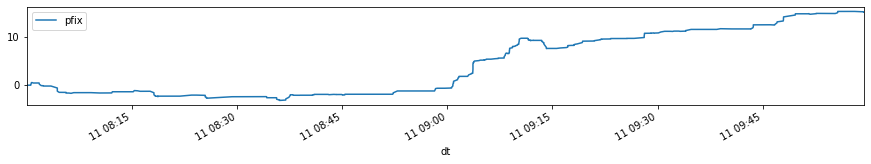

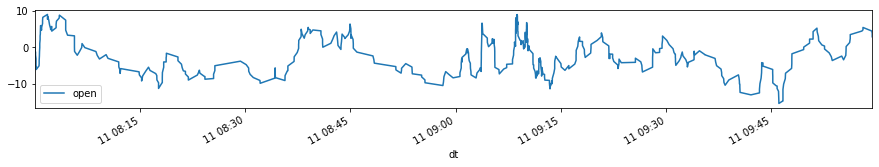

In [210]:
nps = pd.DataFrame(ps)
nps["dt"] = pd.to_datetime(nps["ts"] + 8*3600*1000, unit="ms")
nps.plot(x="dt", y="pfix")
nps.plot(x="dt", y="open")


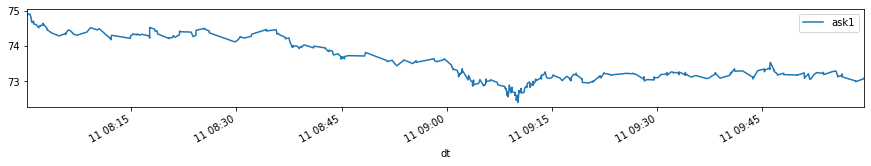

In [211]:
norder["dt"] = pd.to_datetime(norder["uts"] + 8*3600*1000, unit="ms")
norder.plot(x="dt", y="ask1")

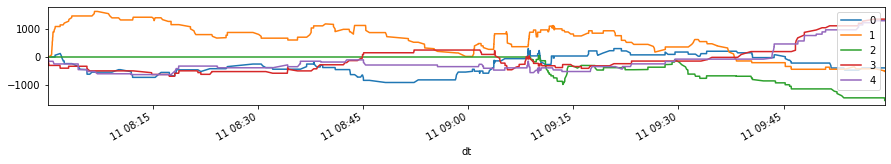

In [212]:
ax = nps.plot(x="dt", y="poss_0", label="0")
nps.plot(x="dt", y="poss_1", label="1", ax=ax)
nps.plot(x="dt", y="poss_2", label="2", ax=ax)
nps.plot(x="dt", y="poss_3", label="3", ax=ax)
nps.plot(x="dt", y="poss_4", label="4", ax=ax)

plt.legend()


In [213]:
nps = pd.read_csv(path_nps, header = None)
nps.columns = ["ts", "symbol", "sid", "pos", "open"]
nps["dt"] = pd.to_datetime(nps["ts"] + 8*3600*1000, unit="ms")


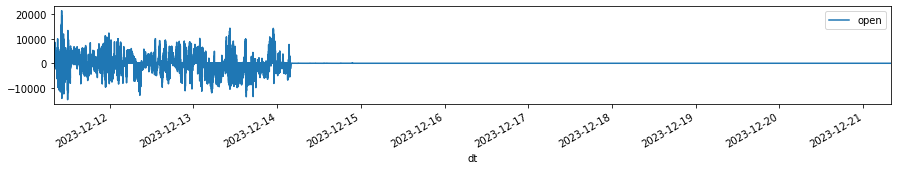

In [214]:
nps.plot(x="dt", y="open")

In [215]:
norder["amountu"].sum() / 2000/5,norder["amountu"].sum()

(3.92359201936648, 39235.9201936648)

In [216]:
# #read tick
# tickpath  ="/data2/zl/l2_trade/tickfactor/SOLUSDT.npy"
# ntick = np.load(tickpath, allow_pickle=True)
# cols = ["ts"]
# for ks in sids:
    
#     cols.append("f_"+str(ks["sid"]))
#     cols.append("s_"+str(ks["sid"]))
# dftick = pd.DataFrame(ntick)
# dftick.columns = cols
# dftick["dt"] = pd.to_datetime(dftick["ts"], unit="s")

In [217]:
# norder["dt"] = pd.to_datetime(norder["cts"], unit="ms")
# for ks in sids:
#     torder = norder[norder["sid"] == ks["sid"]]
#     torder.plot(x="dt", y="price")